In [1]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt

In [2]:
# pulizia per sicurezza

#os.system("rm *.h5")
os.system("rm summary.h5")
os.system("rm *.xml")
os.system("rm *.out")
os.system("rm *.png")

rm: cannot remove '*.out': No such file or directory


0

In [3]:
# VARIABILI DA PAPERMILL se serve (verranno sovrascritte)
pressione_atm = 1.0
moltiplicatore = 1.0
perc_water = 0.15
arricch_max =  45.812 # in percentuale
arricch_min = 5  # in percentuale
t_water = 350.0
t_fuel = 600.0
run_id = "default"

VARIABILI IMPORTANTI

In [4]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters("parametri.txt")

# --- Parametri Geometrici e Logici ---
R_CORE    = p['R_CORE']*moltiplicatore
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']
R_PIPE    = p['R_PIPE']

# --- Parametri Target e Sorgente ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']
S         = p['S']
bin_ris   = p['bin_ris']
batches   = p['batches_fix']
particles = p['particles_fix']

# --- Parametri Pin/Lattice Base ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']

enrich_target = p['enrich_target']

# ==========================================
# SOVRASCRITTURA CON PARAMETRI DI PAPERMILL
# ==========================================
Pressione_funzionamento = pressione_atm * 101325  # atm in Pa
PITCH     = p['PITCH'] * moltiplicatore
mix       = perc_water
T_water   = t_water
T_resto   = t_fuel

# I valori dal txt sono in percentuale, convertiamoli in frazione
enrich_max = arricch_max / 100.0
enrich_min = arricch_min / 100.0


In [5]:
from CoolProp.CoolProp import PropsSI

def densita_mix_dinamica(T_K, P_Pa= Pressione_funzionamento, frac_mass_H2O=mix):
    # Calcolo in kg/m^3 e conversione in g/cm^3
    rho_H2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'Water') / 1000     # D sta per densità
    rho_D2O = PropsSI('D', 'T', T_K, 'P', P_Pa, 'HeavyWater') / 1000
    
    # Calcolo miscela assumendo volumi ideali additivi
    rho_mix = 1 / (frac_mass_H2O / rho_H2O + (1 - frac_mass_H2O) / rho_D2O) # Formula di additività dei volumi specifici
    return rho_mix

print(f"Densità del mix a {T_water} K e {Pressione_funzionamento/1e6} MPa: {densita_mix_dinamica(T_water, Pressione_funzionamento, mix):.4f} g/cm^3")

Densità del mix a 350.0 K e 0.101325 MPa: 1.0629 g/cm^3


MATERIALI

In [6]:
# materiale di rivestimento
cladding = openmc.Material(name='cladding')
cladding.temperature = T_resto
cladding.add_element('Zr', 1.0) 
cladding.set_density('g/cm3', 6.49)

# materiale di moderatore
water = openmc.Material(name='water')
water.temperature = T_water
water.add_nuclide('H1', mix)
water.add_nuclide('H2', 1-mix)
water.add_element('O', 1.0)
water.set_density('g/cm3', densita_mix_dinamica(T_water)) # Usa la densità corretta
water.add_s_alpha_beta('c_D_in_D2O') 
water.add_s_alpha_beta('c_H_in_H2O') 

# aggiungo un riflettore 
reflector = openmc.Material(name='reflector')
reflector.temperature = T_resto
reflector.add_element('C', 1.0)
reflector.set_density('g/cm3', 1.75) 

# voglio una sorgente puntiforme di neutroni in un punto specifico
marker_mat = openmc.Material(name='marker')
marker_mat.temperature = T_resto
marker_mat.set_density('g/cm3', 1e-10) 
marker_mat.add_nuclide('He4', 1.0) 

void_air = openmc.Material(name='void_air')
void_air.temperature = T_resto
void_air.set_density('g/cm3', 1e-10) 
void_air.add_nuclide('N14', 1)

mat_target = openmc.Material(name='mat_target')
mat_target.temperature = T_resto
mat_target.add_nuclide('U235', enrich_target)
mat_target.add_nuclide('U238', 1.0 - enrich_target)
mat_target.add_nuclide('O16', 2.0)
mat_target.set_density('g/cm3', 10.96)
mat_target.volume = np.pi * (R_TARGET**2) * H_TARGET
mat_target.depletable = False

GEOMETRIA

In [7]:
# --- 0. FUNZIONI E CALCOLO NUMERO BARRE ---
import numpy as np

def count_fuel_pins(num_rings, pitch, r_pipe, r_core):
    total_pins = 0
    for i in range(num_rings):
        ring_radius = i * pitch
        if ring_radius >= r_pipe and r_core >= ring_radius:
            total_pins += 1 if i == 0 else (6 * i)
    return total_pins

num_rings = int(np.ceil(R_CORE / PITCH)) + 1
n_barre = count_fuel_pins(num_rings, PITCH, R_PIPE, R_CORE)
print(f"Numero di barre di combustibile effettive: {n_barre}")

# --- 1. PIANI Z (ASSOLUTI) ---
z_bot_ref = openmc.ZPlane(z0=-REF_BOT, boundary_type='vacuum')
z_bot_core = openmc.ZPlane(z0=0.0)
z_top_core = openmc.ZPlane(z0=H_CORE)
z_top_world = openmc.ZPlane(z0=H_CORE + 5.0, boundary_type='vacuum')

# Piani Z Target
z_mid = H_CORE - P_TARGET
z_tgt_bot = openmc.ZPlane(z0=z_mid - (H_TARGET / 2.0))
z_tgt_top = openmc.ZPlane(z0=z_mid + (H_TARGET / 2.0))

# Superficie Sorgente
sphere_src = openmc.Sphere(x0=0, y0=0, z0=H_CORE + 2, r=0.5)

# --- 2. CALCOLO DIMENSIONI E VOLUMI PER DEPLETION ---
n_rings_removed = int(np.ceil(R_PIPE / PITCH))
EDGE_PIPE_LARGE = (n_rings_removed - 0.5) * PITCH
if EDGE_PIPE_LARGE == 0: EDGE_PIPE_LARGE = PITCH

hex_core_edge = num_rings * PITCH
hex_ref_edge = hex_core_edge + REF_SIDE

# Aree esagonali base
A_core = 1.5 * np.sqrt(3) * (hex_core_edge**2)
A_pipe = 1.5 * np.sqrt(3) * (EDGE_PIPE_LARGE**2)
A_ref  = 1.5 * np.sqrt(3) * (hex_ref_edge**2)

# Assegnazione volumi
V_clad_single = np.pi * ((R_FUEL + CLAD_THICK)**2 - R_FUEL**2) * H_CORE
cladding.volume = n_barre * V_clad_single
cladding.depletable = False

V_pins_total = n_barre * np.pi * ((R_FUEL + CLAD_THICK)**2) * H_CORE
water.volume = (A_core - A_pipe) * H_CORE - V_pins_total
water.depletable = False

V_ref_side = (A_ref - A_core) * H_CORE
V_ref_bot  = A_ref * REF_BOT
reflector.volume = V_ref_side + V_ref_bot
reflector.depletable = False

# --- 3. FORME GEOMETRICHE BASE ---
EDGE_FUEL = R_FUEL
EDGE_CLAD = R_FUEL + CLAD_THICK

hex_fuel_prism = openmc.model.hexagonal_prism(edge_length=EDGE_FUEL, orientation='x')
hex_clad_prism = openmc.model.hexagonal_prism(edge_length=EDGE_CLAD, orientation='x')
hex_pipe_prism = openmc.model.hexagonal_prism(edge_length=EDGE_PIPE_LARGE, orientation='x')
cyl_target = openmc.ZCylinder(r=R_TARGET)

# --- 4. UNIVERSI COMBUSTIBILE ---
fuel_mats = []
fuel_universes = []
V_single_pin = np.pi * (R_FUEL**2) * H_CORE

for i in range(num_rings):
    if num_rings > 1:
        e_i = enrich_max - (enrich_max - enrich_min) * (i / (num_rings - 1))
    else:
        e_i = enrich_max

    f = openmc.Material(name=f'fuel_ring_{i}')
    f.temperature = T_resto
    f.add_nuclide('U235', e_i)
    f.add_nuclide('U238', 1.0 - e_i)
    f.add_nuclide('O16', 2.0)
    f.set_density('g/cm3', 10.96)
    
    ring_radius = i * PITCH
    if ring_radius >= R_PIPE and ring_radius <= R_CORE: 
        n_pins_in_ring = 6 * i if i > 0 else 1
        f.volume = n_pins_in_ring * V_single_pin
        f.depletable = True
    else:
        f.depletable = False

    fuel_mats.append(f)
    
    c_f = openmc.Cell(fill=f, region=hex_fuel_prism)
    c_c = openmc.Cell(fill=cladding, region=hex_clad_prism & ~hex_fuel_prism)
    c_w = openmc.Cell(fill=water, region=~hex_clad_prism)
    fuel_universes.append(openmc.Universe(cells=[c_f, c_c, c_w]))

# --- 5. ESPORTAZIONE MATERIALI ---
materials = openmc.Materials(fuel_mats + [cladding, water, reflector, marker_mat, void_air, mat_target])
materials.cross_sections = "/home/bossi_ricky/openmc_data/mcnp_endfb71/cross_sections.xml"
#materials.cross_sections = "/raid1/users/rbossi/MC/Magistrale/openmc_data/cross_sections.xml"

materials.export_to_xml()

# --- 6. LATTICE E ASSEMBLAGGIO FINALE ---
c_water_full = openmc.Cell(fill=water)
u_water = openmc.Universe(cells=[c_water_full])

lattice_universes = []
for i in range(num_rings):
    if i == 0:
        lattice_universes.append([fuel_universes[i]])
    else:
        lattice_universes.append([fuel_universes[i]] * (6 * i))

lattice = openmc.HexLattice(name='core_hex_lattice')
lattice.center = (0.0, 0.0)
lattice.pitch = (PITCH,)
lattice.outer = u_water
lattice.universes = lattice_universes[::-1] 
lattice.orientation = 'x'

prism_core = openmc.model.hexagonal_prism(edge_length=hex_core_edge, orientation='x')
prism_reflector = openmc.model.hexagonal_prism(edge_length=hex_ref_edge, orientation='x', boundary_type='vacuum')

region_core = prism_core & ~hex_pipe_prism & +z_bot_core & -z_top_core
c_main_core = openmc.Cell(fill=lattice, region=region_core)

region_central_hex_total = hex_pipe_prism & +z_bot_core & -z_top_core
region_target_solid = region_central_hex_total & -cyl_target & +z_tgt_bot & -z_tgt_top
region_void_gap = region_central_hex_total & ~region_target_solid

c_target = openmc.Cell(fill=mat_target, region=region_target_solid)
c_void_gap = openmc.Cell(fill=void_air, region=region_void_gap) 

region_ref_side = prism_reflector & ~prism_core & +z_bot_core & -z_top_core
c_ref_side = openmc.Cell(fill=reflector, region=region_ref_side)

region_ref_bot = prism_reflector & +z_bot_ref & -z_bot_core
c_ref_bot = openmc.Cell(fill=reflector, region=region_ref_bot)

c_source_marker = openmc.Cell(fill=marker_mat, region=-sphere_src)
region_top = prism_reflector & +z_top_core & -z_top_world & +sphere_src
c_top_void = openmc.Cell(fill=void_air, region=region_top)

all_cells = [c_main_core, c_target, c_void_gap, c_ref_side, c_ref_bot, c_source_marker, c_top_void]
geometry = openmc.Geometry(all_cells)
geometry.export_to_xml()
print("Geometria generata correttamente.")

Numero di barre di combustibile effettive: 390
Geometria generata correttamente.


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:121: FutureWarning: The hexagonal_prism(...) function has been replaced by the HexagonalPrism(...) class. Future versions of OpenMC will not accept hexagonal_prism.
  warn("The hexagonal_prism(...) function has been replaced by the "


PLOTTING

/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/plots.py:1307: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(



VISUALIZZAZIONE GEOMETRIA

1. VISTA DALL'ALTO (Piano XY nel Core)


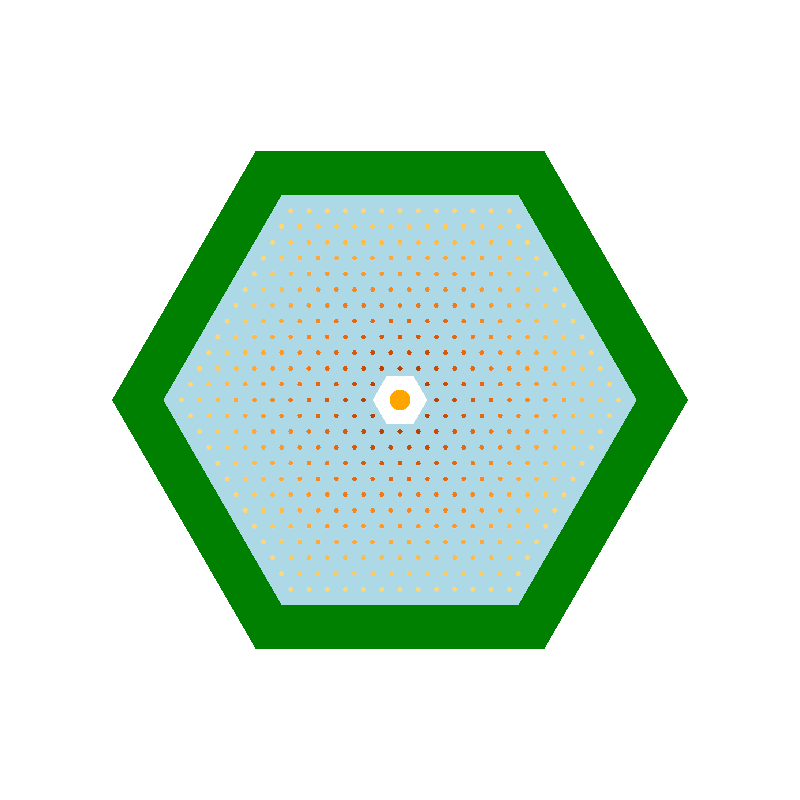

2. VISTA LATERALE (Piano XZ)


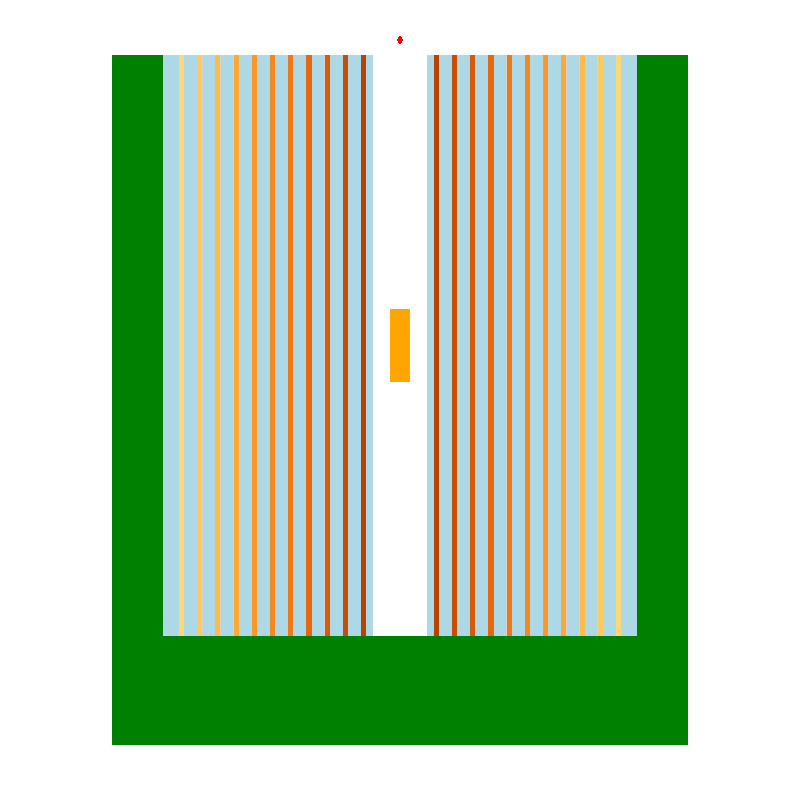

In [8]:
color_map = {
    cladding: 'lightgray',  # Cladding
    water: 'lightblue',     # Moderatore (acqua)
    reflector: 'green',     # Riflettore
    marker_mat: 'red' ,     # Marker sorgente
    void_air: 'white',      # Vuoto (aria)
    mat_target: 'orange'   # Target
}

cmap = plt.get_cmap('YlOrBr')

for i, f in enumerate(fuel_mats):
    if num_rings > 1:
        # Normalizziamo l'indice: 0 (centro, max arricchimento) -> 1 (esterno, min arricchimento)
        norm_val = i / (num_rings - 1)
    else:
        norm_val = 0.5
        
    rgba = cmap(0.9 - norm_val * 0.6)
    
    # OpenMC richiede tuple RGB con valori interi 0-255
    rgb_color = (int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))
    color_map[f] = rgb_color

# A. Vista dall'alto (Sezione nel mezzo del core)
p1 = openmc.Plot()
p1.basis = 'xy'
p1.origin = (0.0, 0.0, H_CORE / 2.0)
p1.width = (3 * (R_CORE + REF_SIDE + 2.0), 3 * (R_CORE + REF_SIDE + 2.0))
p1.pixels = (800, 800)
p1.color_by = 'material'
p1.colors = color_map
p1.filename = 'reactor_xy'

# B. Vista laterale (Sezione verticale XZ)
p2 = openmc.Plot()
p2.basis = 'xz'
p2.origin = (0.0, 0.0, (H_CORE - REF_BOT) / 2.0) 
p2.width = (3 * (R_CORE + REF_SIDE + 2.0), H_CORE + REF_BOT + 15.0)
p2.pixels = (800, 800)
p2.color_by = 'material'
p2.colors = color_map
p2.filename = 'reactor_xz'

# Esporto tutti i plot nel file XML
plots = openmc.Plots([p1, p2])
plots.export_to_xml()

# Eseguo il plotter: ho rimosso open_browser=False che causava l'errore
# OpenMC genererà i file .png basandosi sui nomi definiti (reactor_xy.png, ecc.)
openmc.plot_geometry() 

print("\n" + "="*30)
print("VISUALIZZAZIONE GEOMETRIA")
print("="*30 + "\n")

print("1. VISTA DALL'ALTO (Piano XY nel Core)")
display(Image('reactor_xy.png'))

print("2. VISTA LATERALE (Piano XZ)")
display(Image('reactor_xz.png'))

SETTINGS FIXED

In [9]:
# Lettura dello spettro in energia
data = np.loadtxt("synchrotron_1_37_MeV.txt")
energy_midpoints, pdf_array = data[:,0], data[:,1]
energy_dist = openmc.stats.Tabular(energy_midpoints, pdf_array, interpolation='linear-linear')

# Definizione della sorgente
source = openmc.IndependentSource()
source.space = openmc.stats.Point((0, 0, H_CORE + 2.0))
source.angle = openmc.stats.Monodirectional((0, 0, -1))
source.energy = energy_dist
source.particle = 'neutron'

# Impostazioni di simulazione
settings = openmc.Settings()

# Gestione particelle perse (alza il limite se la geometria è complessa ma corretta)
settings.max_lost_particles = 50

settings.batches = batches
settings.particles = particles
settings.run_mode = 'fixed source'

settings.cutoff = {'weight': 1.0e-5, 'energy_photon': 1.0e6} # cutoff a 1 MeV per i fotoni, così non simulo fotoni che non mi interessano
settings.temperature = {'method': 'interpolation'}

settings.max_collisions = 1000

settings.source = source

settings.photon_transport = True
settings.photonuclear_physics = True
settings.create_fission_neutrons = True

settings.export_to_xml()

# METTI TRACKING DEI NEUTRONI

TALLIES

In [10]:
tallies = openmc.Tallies()
#
## --- A. MESH E TALLY ASSIALE ---
#mesh_z = openmc.RegularMesh()
#mesh_z.dimension = [1, 1, bin_ris]
#mesh_z.lower_left = [-R_CORE, -R_CORE, 0.0]
#mesh_z.upper_right = [R_CORE, R_CORE, H_CORE]
#
## --- B. MESH E TALLY 2D (MAPPA FISSIONI) ---
#bound_xy = R_CORE + REF_SIDE 
#mesh_2d = openmc.RegularMesh()
#mesh_2d.dimension = [bin_ris, bin_ris, 1]
#mesh_2d.lower_left = [-bound_xy, -bound_xy, H_CORE/2.0 - 0.25] # mesh su una fetta alta 0.5 cm al centro del core
#mesh_2d.upper_right = [bound_xy, bound_xy, H_CORE/2.0 + 0.25]
#
#mesh_2d_flux = openmc.RegularMesh()     # mesh per il flusso in mezzo reattore
#mesh_2d_flux.dimension = [bin_ris, bin_ris, 1]
#mesh_2d_flux.lower_left = [0 , -bound_xy, H_CORE/2.0 - 0.25]
#mesh_2d_flux.upper_right = [bound_xy, bound_xy, H_CORE/2.0 + 0.25]   
#
#filter_termico = openmc.EnergyFilter([0.0, 0.625])
#filter_veloce = openmc.EnergyFilter([0.625, 20.0e6])
#neutron_filter = openmc.ParticleFilter(['neutron'])
#photon_filter = openmc.ParticleFilter(['photon'])
#
## ---------------------------------------------------------------------------------------------------------------------
#
## --- Tally per i profili assiali di neutroni e fotoni ---
#tally_n = openmc.Tally(name='profilo_neutroni')
#tally_n.filters = [openmc.MeshFilter(mesh_z), neutron_filter]
#tally_n.scores = ['flux']
#tallies.append(tally_n)
#tally_p = openmc.Tally(name='profilo_fotoni')
#tally_p.filters = [openmc.MeshFilter(mesh_z), photon_filter]
#tally_p.scores = ['flux']
#tallies.append(tally_p)
#
## Tally mappa fission
#tally_map = openmc.Tally(name='mappa_fissioni')
#tally_map.filters = [openmc.MeshFilter(mesh_2d), neutron_filter]
#tally_map.scores = ['nu-fission', 'fission', 'absorption', 'flux']
#tallies.append(tally_map)
#
#tally_flusso_termico = openmc.Tally(name='flusso_termico')
#tally_flusso_termico.filters = [openmc.MeshFilter(mesh_2d_flux), filter_termico, neutron_filter]
#tally_flusso_termico.scores = ['flux']
#tallies.append(tally_flusso_termico)
#
#tally_flusso_veloce = openmc.Tally(name='flusso_veloce')
#tally_flusso_veloce.filters = [openmc.MeshFilter(mesh_2d_flux),  filter_veloce, neutron_filter]
#tally_flusso_veloce.scores = ['flux']
#tallies.append(tally_flusso_veloce)
#
## Tally spettro energetico totale (neutroni + fotoni)
#energies = np.logspace(-3, 7.6, 501)    #corrisponde a circa 40 Mev
#tally_spec = openmc.Tally(name='spettro_energetico')
#tally_spec.filters = [openmc.EnergyFilter(energies), openmc.ParticleFilter(['neutron', 'photon'])]
#tally_spec.scores = ['flux']
#tallies.append(tally_spec)

#fission_tot = openmc.Tally(name='fission_tot')
#fission_tot.scores = ['fission']
#tallies.append(fission_tot)

tallies.export_to_xml()


## Analisi della Bruciatura del Reattore (Burnup) e Decadimento

L'obiettivo di questa simulazione è modellare l'evoluzione della composizione isotopica dei materiali del reattore sotto l'effetto di un flusso neutronico costante (**fase di Burnup**) e la successiva evoluzione dei veleni e dei prodotti di fissione dopo lo spegnimento della sorgente (**fase di Decadimento**).

---

### 1. Le Equazioni di Bateman

L'evoluzione della densità atomica di un nuclide $i$ nel tempo è governata dalle **Equazioni di Bateman**, un sistema di equazioni differenziali ordinarie del primo ordine accoppiate:

$$
\frac{dN_i(t)}{dt} =
\sum_{j \neq i} \left[ \phi \, \sigma_{j \to i} + \lambda_{j \to i} \right] N_j(t)
- \left[ \phi \, \sigma_{a,i} + \lambda_i \right] N_i(t)
$$

Dove:

- $N_i(t)$: densità atomica dell'isotopo $i$
- $\phi$: flusso neutronico scalare (calcolato via Monte Carlo)
- $\sigma_{j \to i}$: sezione d'urto microscopica per la produzione di $i$ da $j$ (es. cattura radiativa)
- $\lambda_{j \to i}$: costante di decadimento radioattivo da $j$ a $i$
- $\sigma_{a,i}$: sezione d'urto di assorbimento totale del nuclide $i$
- $\lambda_i$: costante di decadimento totale del nuclide $i$

Regimi fisici:

- **Reattore acceso ($S > 0$):** attivi sia reazioni nucleari che decadimenti
- **Reattore spento ($S = 0$):** $\phi = 0$ ⇒ solo decadimento radioattivo

---

### 2. Accoppiamento Monte Carlo - Bateman

OpenMC utilizza un approccio accoppiato:

### Solver di Trasporto (Monte Carlo)
- Simula neutroni e fotoni
- Calcola spettro energetico e flusso $\phi$
- In modalità *Fixed Source*: il flusso dipende da:
  - intensità della sorgente $S$
  - moltiplicazione subcritica

### Solver di Depletion
- Usa i tassi di reazione come coefficienti
- Risolve le equazioni di Bateman su un intervallo $\Delta t$

### Aggiornamento iterativo
1. Calcolo trasporto
2. Risoluzione Bateman
3. Aggiornamento materiali
4. Ripetizione per lo step successivo

---

### 3. Metodi di Integrazione Temporale

Predictor-Corrector (es. `PredictorIntegrator`, `CECMIntegrator`)

#### Predictor
- Calcola i tassi a $t_n$
- Stima la composizione a $t_{n+1}$

#### Corrector
- Ricalcola il trasporto su composizione stimata
- Media i tassi di reazione
- Migliora la precisione (soprattutto per step lunghi)

---

### Caso Spegnimento

Quando $S = 0$:

- niente trasporto Monte Carlo
- solo decadimento

OpenMC usa:
- soluzione analitica **oppure**
- metodo **CRAM (Chebyshev Rational Approximation Method)**
   molto più veloce e stabile numericamente

---

### 4. Monitoraggio dei Veleni Nucleari

#### Xenon-135 ($^{135}$Xe)

- Origine:
  $$
  ^{135}\text{I} \rightarrow ^{135}\text{Xe}
  $$
- Sezione d'urto enorme:
  $$
  \sigma \approx 2 \times 10^6 \, \text{barn}
  $$

#### Comportamento:
- Durante funzionamento: viene bruciato dal flusso
- Dopo spegnimento:
  - continua a essere prodotto da I-135
  - **non viene più distrutto**
  - ⇒ **picco dello Xenon**


#### Samario-149 ($^{149}$Sm)

- Origine:
  $$
  ^{149}\text{Pm} \rightarrow ^{149}\text{Sm}
  $$

#### Comportamento:
- veleno **stabile**
- non decade
- si accumula fino a:
  - **plateau asintotico** dopo spegnimento

---

## Sintesi operativa

- Burnup → competizione tra produzione e distruzione isotopica
- Shutdown → solo decadimenti → dinamica dominata da catene di decadimento
- Xenon → effetto transitorio critico
- Samario → effetto permanente



In [ ]:
import openmc.deplete

# Questo sostituisce la necessità di esportare manualmente e chiamare openmc.run()
model = openmc.Model(geometry=geometry, materials=materials, settings=settings, tallies=tallies)

# 2. Definizione del file della catena di decadimento
# NOTA: Devi avere un file chain.xml compatibile con la tua libreria ENDF/B-VII.1
#chain_file = "/raid1/users/rbossi/MC/Magistrale/openmc_data/chain_endfb71.xml" 
chain_file = "/home/bossi_ricky/openmc_data/mcnp_endfb71/chain_endfb71_pwr.xml"

# 3. Creazione dell'Operatore Accoppiato
operator = openmc.deplete.CoupledOperator(
    model, 
    chain_file,
    normalization_mode="source-rate" 
)

: 

In [ ]:
# --- 1. SETUP VETTORI TEMPORALI E SORGENTE ---

# Fase 1: Bruciatura a piena potenza (S costante) per 100 giorni
# Diviso in 10 step da 10 giorni per aggiornare il trasporto neutronico
giorni_on = [10.0] * 10
source_on = [S] * len(giorni_on)

# Fase 2: Spegnimento e Decadimento (S = 0)
# Step molto fitti all'inizio per campionare il transitorio dello Xenon-135 (picco a ~11 ore dallo spegnimento)
giorni_off = [0.1, 0.4, 0.5, 1.0, 3.0, 10.0, 30.0, 55.0]
source_off = [0.0] * len(giorni_off)

time_steps = giorni_on + giorni_off
source_rates = source_on + source_off

# --- 2. INTEGRAZIONE NUMERICA ---

integrator = openmc.deplete.PredictorIntegrator(
    operator, 
    time_steps, 
    source_rates=source_rates, 
    timestep_units='d'
)

import warnings
# Silenzia i warning di Python e OpenMC a livello di interprete
warnings.filterwarnings("ignore")

# Avvio del calcolo
integrator.integrate()

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%%
                 #####################

 Reading O from /home/bossi_ricky/openmc_data/mcnp_endfb71/photon/O.h5 
 Reading O16 from /home/bossi_ricky/openmc_data/mcnp_endfb71/photonuclear/O16.h5
 Reading O17 from /home/bossi_ricky/openmc_data/mcnp_endfb71/O17.h5
 Reading O17 from /home/bossi_ricky/openmc_data/mcnp_endfb71/photonuclear/O17.h5
 Reading C0 from /home/bossi_ricky/openmc_data/mcnp_endfb71/C0.h5
 Reading C from /home/bossi_ricky/openmc_data/mcnp_endfb71/photon/C.h5 
 Reading He4 from /home/bossi_ricky/openmc_data/mcnp_endfb71/He4.h5
 Reading He from /home/bossi_ricky/openmc_data/mcnp_endfb71/photon/He.h5 
 Reading N14 from /home/bossi_ricky/openmc_data/mcnp_endfb71/N14.h5


 Reading N from /home/bossi_ricky/openmc_data/mcnp_endfb71/photon/N.h5 
 Reading N14 from /home/bossi_ricky/openmc_data/mcnp_endfb71/photonuclear/N14.h5
 Reading U235 from /home/bossi_ricky/openmc_data/mcnp_endfb71/U235.h5
 Reading U from /home/bossi_ricky/openmc_data/mcnp_endfb71/photon/U.h5 
 Reading U235 from
 /home/bossi_ricky/openmc_data/mcnp_endfb71/photonuclear/U235.h5
 Reading U238 from /home/bossi_ricky/openmc_data/mcnp_endfb71/U238.h5
 Reading U238 from
 /home/bossi_ricky/openmc_data/mcnp_endfb71/photonuclear/U238.h5
 Reading c_D_in_D2O from
 /home/bossi_ricky/openmc_data/mcnp_endfb71/c_D_in_D2O.h5
 Reading c_H_in_H2O from
 /home/bossi_ricky/openmc_data/mcnp_endfb71/c_H_in_H2O.h5
 Minimum neutron data temperature: 294 K
 Maximum neutron data temperature: 900 K
 Reading tallies XML file...
 Preparing distributed cell instances...
 Reading plot XML file...
 Writing summary.h5 file...


[openmc.deplete] t=0.0 s, dt=864000.0 s, source=2.02e+17
 Reading H3 from /home/bossi_ricky/openmc_data/mcnp_endfb71/H3.h5
 Reading He3 from /home/bossi_ricky/openmc_data/mcnp_endfb71/He3.h5
 Reading Li6 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Li6.h5
 Reading Li from /home/bossi_ricky/openmc_data/mcnp_endfb71/photon/Li.h5 
 Reading Li7 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Li7.h5
 Reading Be7 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Be7.h5
 Reading Be from /home/bossi_ricky/openmc_data/mcnp_endfb71/photon/Be.h5 
 Reading Be9 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Be9.h5


 Reading Be9 from /home/bossi_ricky/openmc_data/mcnp_endfb71/photonuclear/Be9.h5
 Reading B10 from /home/bossi_ricky/openmc_data/mcnp_endfb71/B10.h5
 Reading B from /home/bossi_ricky/openmc_data/mcnp_endfb71/photon/B.h5 
 Reading B11 from /home/bossi_ricky/openmc_data/mcnp_endfb71/B11.h5


...

 Reading Cf246 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Cf246.h5
 Reading Cf from /home/bossi_ricky/openmc_data/mcnp_endfb71/photon/Cf.h5 
 Reading Cf248 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Cf248.h5
 Reading Cf249 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Cf249.h5
 Reading Cf250 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Cf250.h5


 Reading Cf251 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Cf251.h5
 Reading Cf252 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Cf252.h5
 Reading Cf253 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Cf253.h5


 Reading Cf254 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Cf254.h5
 Reading Es251 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Es251.h5
 Reading Es from /home/bossi_ricky/openmc_data/mcnp_endfb71/photon/Es.h5 
 Reading Es252 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Es252.h5
 Reading Es253 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Es253.h5
 Reading Es254 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Es254.h5
 Reading Es254_m1 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Es254_m1.h5
 Reading Es255 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Es255.h5
 Reading Fm255 from /home/bossi_ricky/openmc_data/mcnp_endfb71/Fm255.h5


 Reading Fm from /home/bossi_ricky/openmc_data/mcnp_endfb71/photon/Fm.h5 
 Minimum photonuclear physics energy: 9.999999999999999e-06 eV for Np237
 Maximum neutron transport energy: 8100000 eV for Be7



 ===============>     FIXED SOURCE TRANSPORT SIMULATION     <===============

 Simulating batch 1
